In [2]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [3]:
os = platform.system()

# 한글이 깨지지 않는 폰트로 수정
if os == 'Windows':
    plt.rc('font', family= 'Malgun Gothic')
    
elif os == 'Darwin':
    plt.rc('font', family= 'AppleGothic')

elif os == 'Linux':
    plt.rc('font', family= 'NanumGothic')

else:
    print(f'{os} is not set')

In [4]:
df = pd.read_csv("../data/ai4i2020.csv")

In [5]:
df = df.rename(columns={
    "UDI": "고유번호",
    "Product ID": "제품ID",
    "Type": "제품등급",
    "Air temperature [K]": "주변온도_K",
    "Process temperature [K]": "공정온도_K",
    "Rotational speed [rpm]": "회전속도_rpm",
    "Torque [Nm]": "토크_Nm",
    "Tool wear [min]": "공구마모_분",
    "Machine failure": "기계고장",
    "TWF": "공구마모고장",
    "HDF": "열방출고장",
    "PWF": "동력고장",
    "OSF": "과부하고장",
    "RNF": "무작위고장"
})

In [6]:
df.head()

,고유번호,제품ID,제품등급,주변온도_K,공정온도_K,회전속도_rpm,토크_Nm,공구마모_분,기계고장,공구마모고장,열방출고장,동력고장,과부하고장,무작위고장
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [169]:
df.describe()

,고유번호,주변온도_K,공정온도_K,회전속도_rpm,토크_Nm,공구마모_분,기계고장,공구마모고장,열방출고장,동력고장,과부하고장,무작위고장
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [170]:
len(df)

10000

In [171]:
df['기계고장'].value_counts(normalize=True)*100

기계고장
0    96.61
1     3.39
Name: proportion, dtype: float64

In [172]:
df['기계고장'].value_counts()

기계고장
0    9661
1     339
Name: count, dtype: int64

In [173]:
df['공구마모고장'].value_counts()

공구마모고장
0    9954
1      46
Name: count, dtype: int64

In [174]:
df['열방출고장'].value_counts()

열방출고장
0    9885
1     115
Name: count, dtype: int64

In [175]:
df['동력고장'].value_counts()

동력고장
0    9905
1      95
Name: count, dtype: int64

In [176]:
df['과부하고장'].value_counts()

과부하고장
0    9902
1      98
Name: count, dtype: int64

In [177]:
df['무작위고장'].value_counts()

무작위고장
0    9981
1      19
Name: count, dtype: int64

In [178]:
fails = ['공구마모고장','열방출고장','동력고장','과부하고장','무작위고장']

In [179]:
df_fail = df.drop(columns=(fails+['고유번호']))

In [180]:
df_fail['기계적출력'] = df_fail['토크_Nm'] * df_fail['회전속도_rpm']

In [181]:
# 토크와 회전속도가 커질수록 값이 커지게 하고 싶음 => 지수함수
#df_fail['토크_Nm_지수'] = 2 ** df_fail['토크_Nm']
#df_fail['회전속도_rpm_지수'] = 2 ** df_fail['회전속도_rpm']
# -> 이렇게 하면 overflow가 되어서 문제가 발생

In [182]:
# 스케일링 진행 후에 지수함수 적용
scaler = MinMaxScaler()

df_fail[['토크_지수', '회전속도_지수']] = np.exp(
    scaler.fit_transform(df_fail[['토크_Nm', '회전속도_rpm']])
)

In [183]:
df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


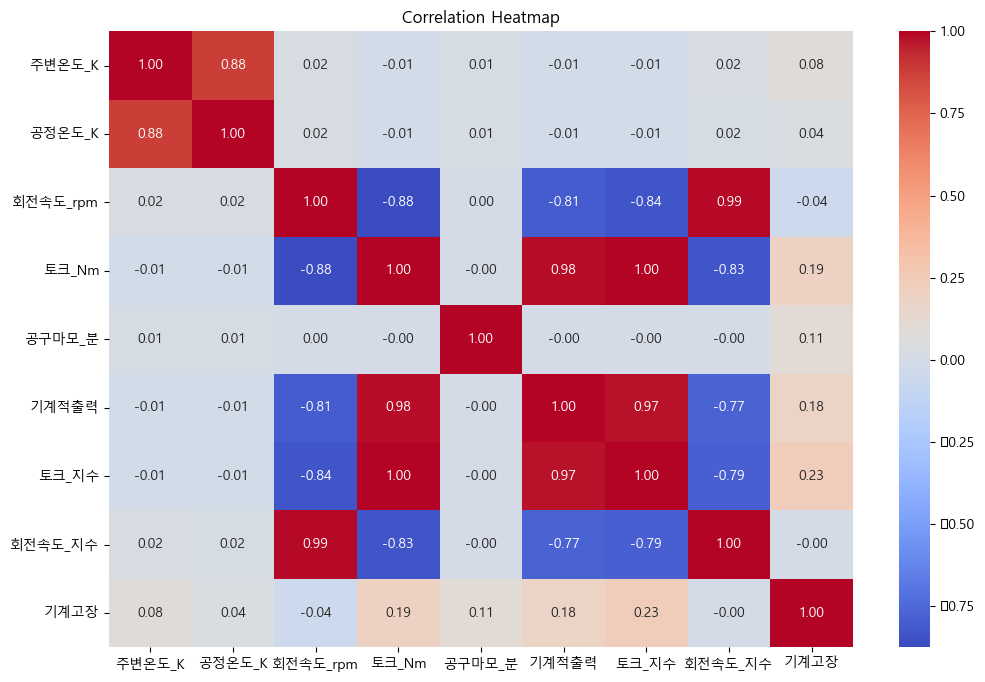

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

회전속도_지수가 0에 가까움. 이거는 필요 없을 것 같음

In [185]:
df_fail = df_fail.drop(columns='회전속도_지수')

In [186]:
df_fail['마모_지수'] = np.exp(
    scaler.fit_transform(df_fail[['공구마모_분']])
).ravel()

In [187]:
df_fail['주변온도_지수'] = np.exp(
    scaler.fit_transform(df_fail[['주변온도_K']])
).ravel()

c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


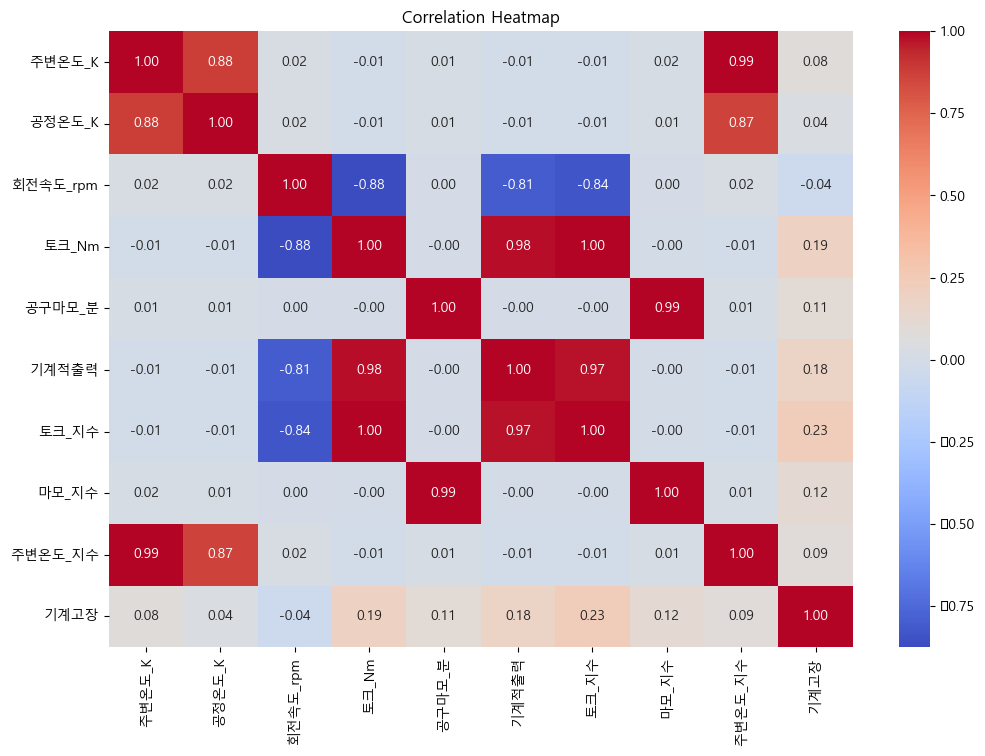

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

plt.figure(figsize=(12, 8))

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()